# 05 — Análises para o Power BI
## Pipeline ETL End-to-End — Olist E-commerce Dataset

Etapa final: queries analíticas no Data Warehouse e
exportação das tabelas agregadas para o Power BI.

**Análises geradas:**
1. Receita e volume mensal
2. Performance por categoria de produto
3. Satisfação e logística por estado
4. Tempo de entrega e atrasos
5. Performance dos vendedores

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine, text
from google.colab import drive

# Montar Drive
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount('/content/drive')

# Conexão SQLite
DB_PATH     = "/content/drive/MyDrive/olist-pipeline/olist_dw.db"
EXPORT_PATH = "/content/drive/MyDrive/olist-pipeline/export"
os.makedirs(EXPORT_PATH, exist_ok=True)

engine = create_engine(f"sqlite:///{DB_PATH}")

with engine.connect() as conn:
    count = conn.execute(
        text("SELECT COUNT(*) FROM fato_pedidos")
    ).fetchone()[0]

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

print("✅ Conexão estabelecida")
print(f"   Banco: {DB_PATH}")
print(f"   fato_pedidos: {count:,} linhas")
print(f"   Exportações em: {EXPORT_PATH}")

✅ Conexão estabelecida
   Banco: /content/drive/MyDrive/olist-pipeline/olist_dw.db
   fato_pedidos: 119,137 linhas
   Exportações em: /content/drive/MyDrive/olist-pipeline/export


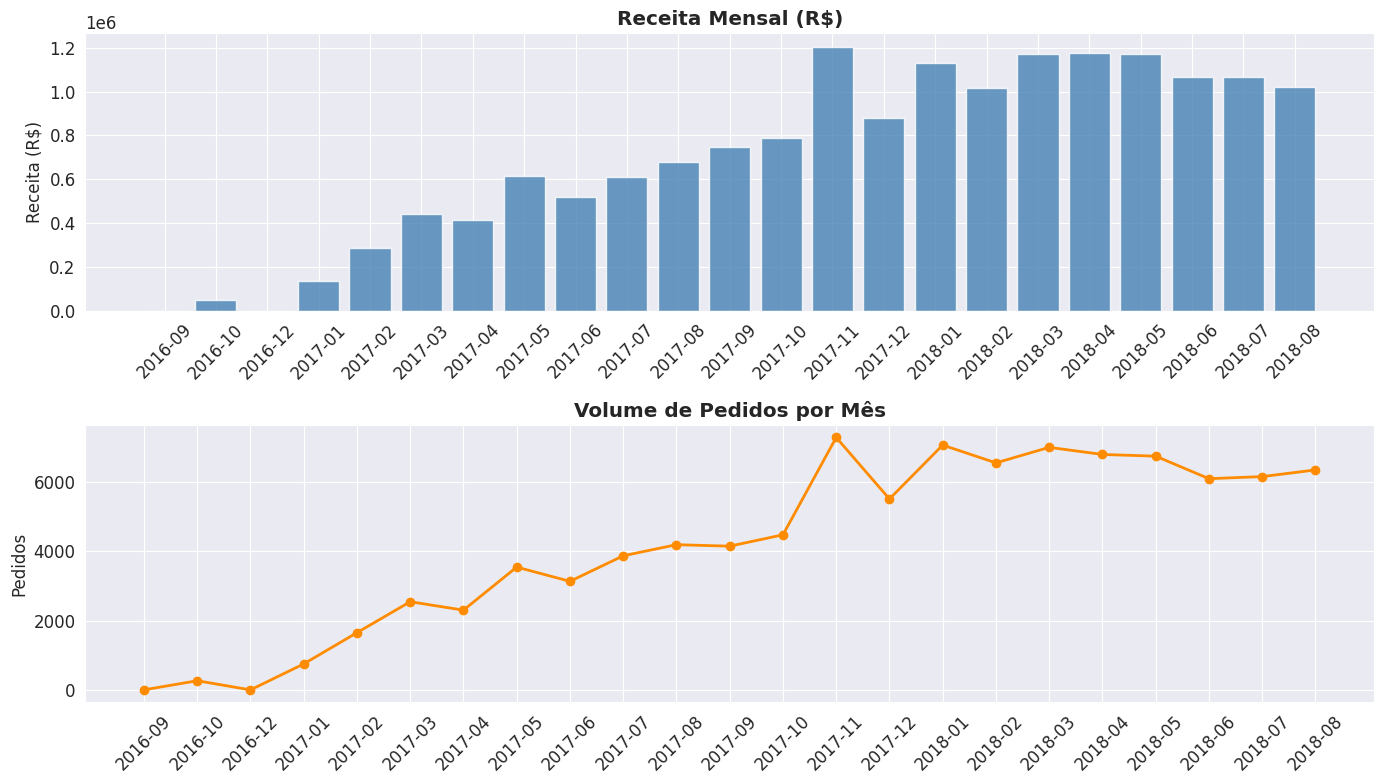

✅ receita_mensal exportado (23 linhas)


In [11]:
query = """
    SELECT purchase_year  AS ano,
           purchase_month AS mes,
           COUNT(DISTINCT order_id)     AS pedidos,
           ROUND(SUM(item_total), 2)    AS receita,
           ROUND(AVG(item_price), 2)    AS ticket_medio,
           ROUND(AVG(item_freight), 2)  AS frete_medio
    FROM fato_pedidos
    WHERE order_status = 'delivered'
    GROUP BY purchase_year, purchase_month
    ORDER BY purchase_year, purchase_month
"""

df_mensal = pd.read_sql(text(query), engine)
df_mensal["periodo"] = (
    df_mensal["ano"].astype(str) + "-" +
    df_mensal["mes"].astype(str).str.zfill(2)
)
df_mensal.to_csv(f"{EXPORT_PATH}/receita_mensal.csv", index=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.bar(df_mensal["periodo"], df_mensal["receita"],
        color="steelblue", alpha=0.8)
ax1.set_title("Receita Mensal (R$)", fontweight="bold")
ax1.set_ylabel("Receita (R$)")
ax1.tick_params(axis="x", rotation=45)

ax2.plot(df_mensal["periodo"], df_mensal["pedidos"],
         marker="o", color="darkorange", linewidth=2)
ax2.set_title("Volume de Pedidos por Mês", fontweight="bold")
ax2.set_ylabel("Pedidos")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{EXPORT_PATH}/receita_mensal.png", dpi=150)
plt.show()
print(f"✅ receita_mensal exportado ({len(df_mensal)} linhas)")

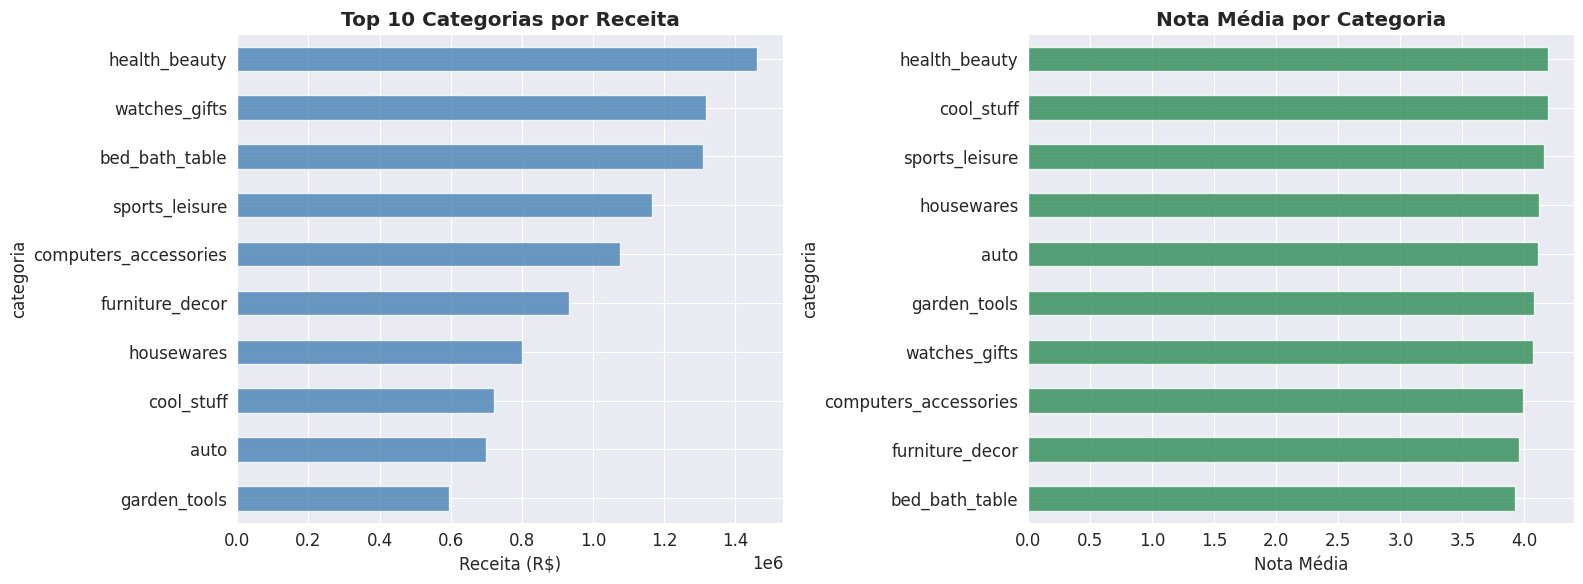

✅ performance_categorias exportado (72 linhas)


In [12]:
query = """
    SELECT p.product_category_name_english  AS categoria,
           COUNT(DISTINCT f.order_id)        AS pedidos,
           ROUND(SUM(f.item_total), 2)       AS receita,
           ROUND(AVG(f.item_price), 2)       AS ticket_medio,
           ROUND(AVG(f.review_score), 2)     AS nota_media
    FROM fato_pedidos f
    JOIN dim_produtos p ON f.product_id = p.product_id
    WHERE f.order_status = 'delivered'
      AND p.product_category_name_english IS NOT NULL
    GROUP BY p.product_category_name_english
    ORDER BY receita DESC
"""

df_categoria = pd.read_sql(text(query), engine)
df_categoria.to_csv(f"{EXPORT_PATH}/performance_categorias.csv", index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_categoria.head(10).sort_values("receita").plot(
    kind="barh", x="categoria", y="receita",
    ax=ax1, color="steelblue", alpha=0.8, legend=False
)
ax1.set_title("Top 10 Categorias por Receita", fontweight="bold")
ax1.set_xlabel("Receita (R$)")

df_categoria.head(10).sort_values("nota_media").plot(
    kind="barh", x="categoria", y="nota_media",
    ax=ax2, color="seagreen", alpha=0.8, legend=False
)
ax2.set_title("Nota Média por Categoria", fontweight="bold")
ax2.set_xlabel("Nota Média")

plt.tight_layout()
plt.savefig(f"{EXPORT_PATH}/performance_categorias.png", dpi=150)
plt.show()
print(f"✅ performance_categorias exportado ({len(df_categoria)} linhas)")

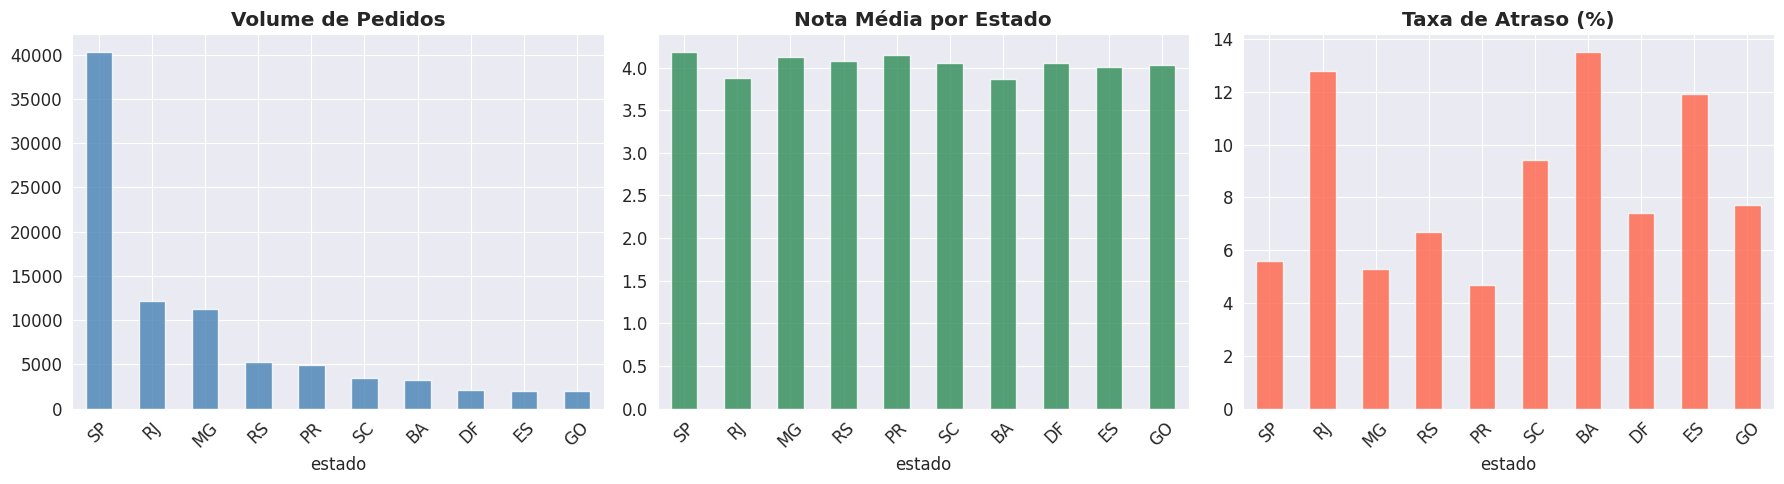

✅ satisfacao_estados exportado (27 linhas)


In [13]:
query = """
    SELECT customer_state                   AS estado,
           COUNT(DISTINCT order_id)          AS pedidos,
           ROUND(AVG(review_score), 2)       AS nota_media,
           ROUND(AVG(delivery_days), 1)      AS prazo_medio_dias,
           ROUND(
               100.0 * SUM(CASE WHEN is_late=1 THEN 1 ELSE 0 END)
               / COUNT(*), 1
           )                                 AS pct_atraso
    FROM fato_pedidos
    WHERE order_status = 'delivered'
      AND review_score IS NOT NULL
    GROUP BY customer_state
    ORDER BY pedidos DESC
"""

df_estado = pd.read_sql(text(query), engine)
df_estado.to_csv(f"{EXPORT_PATH}/satisfacao_estados.csv", index=False)

df_top = df_estado.head(10)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_top.plot(kind="bar", x="estado", y="pedidos",
            ax=axes[0], color="steelblue", alpha=0.8, legend=False)
axes[0].set_title("Volume de Pedidos", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

df_top.plot(kind="bar", x="estado", y="nota_media",
            ax=axes[1], color="seagreen", alpha=0.8, legend=False)
axes[1].set_title("Nota Média por Estado", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

df_top.plot(kind="bar", x="estado", y="pct_atraso",
            ax=axes[2], color="tomato", alpha=0.8, legend=False)
axes[2].set_title("Taxa de Atraso (%)", fontweight="bold")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{EXPORT_PATH}/satisfacao_estados.png", dpi=150)
plt.show()
print(f"✅ satisfacao_estados exportado ({len(df_estado)} linhas)")

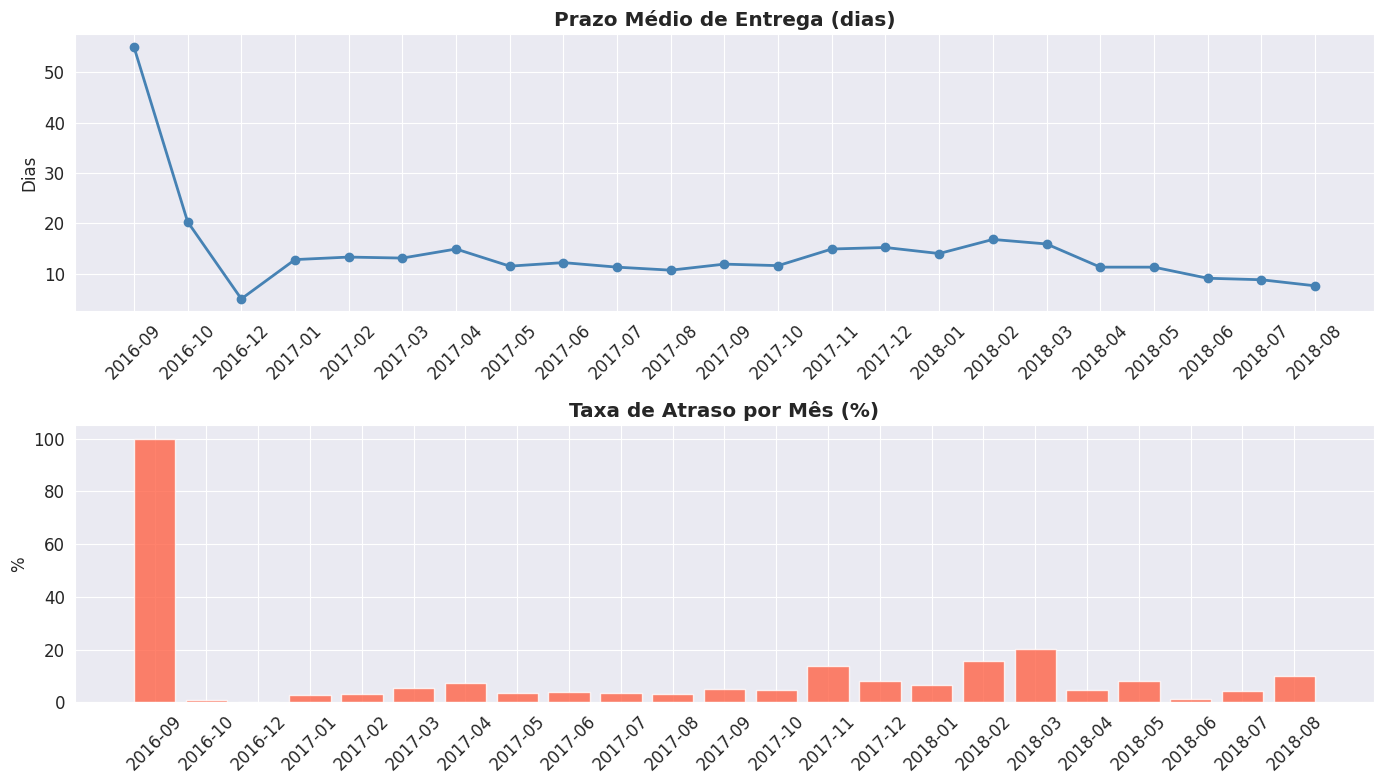

✅ tempo_entrega exportado (23 linhas)


In [14]:
query = """
    SELECT purchase_year  AS ano,
           purchase_month AS mes,
           ROUND(AVG(delivery_days), 1)  AS prazo_medio,
           MIN(delivery_days)             AS prazo_minimo,
           MAX(delivery_days)             AS prazo_maximo,
           SUM(CASE WHEN is_late=1 THEN 1 ELSE 0 END) AS atrasados,
           COUNT(*)                       AS total_entregas,
           ROUND(
               100.0 * SUM(CASE WHEN is_late=1 THEN 1 ELSE 0 END)
               / COUNT(*), 1
           )                             AS pct_atraso
    FROM fato_pedidos
    WHERE order_status = 'delivered'
      AND delivery_days > 0
    GROUP BY purchase_year, purchase_month
    ORDER BY purchase_year, purchase_month
"""

df_entrega = pd.read_sql(text(query), engine)
df_entrega["periodo"] = (
    df_entrega["ano"].astype(str) + "-" +
    df_entrega["mes"].astype(str).str.zfill(2)
)
df_entrega.to_csv(f"{EXPORT_PATH}/tempo_entrega.csv", index=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(df_entrega["periodo"], df_entrega["prazo_medio"],
         marker="o", color="steelblue", linewidth=2)
ax1.set_title("Prazo Médio de Entrega (dias)", fontweight="bold")
ax1.set_ylabel("Dias")
ax1.tick_params(axis="x", rotation=45)

ax2.bar(df_entrega["periodo"], df_entrega["pct_atraso"],
        color="tomato", alpha=0.8)
ax2.set_title("Taxa de Atraso por Mês (%)", fontweight="bold")
ax2.set_ylabel("%")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{EXPORT_PATH}/tempo_entrega.png", dpi=150)
plt.show()
print(f"✅ tempo_entrega exportado ({len(df_entrega)} linhas)")

In [15]:
query = """
    SELECT f.seller_id,
           s.seller_state               AS estado,
           s.seller_city                AS cidade,
           COUNT(DISTINCT f.order_id)   AS pedidos,
           ROUND(SUM(f.item_total), 2)  AS receita,
           ROUND(AVG(f.item_price), 2)  AS ticket_medio,
           ROUND(AVG(f.review_score), 2) AS nota_media,
           ROUND(
               100.0 * SUM(CASE WHEN f.is_late=1 THEN 1 ELSE 0 END)
               / COUNT(*), 1
           )                            AS pct_atraso
    FROM fato_pedidos f
    JOIN dim_vendedores s ON f.seller_id = s.seller_id
    WHERE f.order_status = 'delivered'
    GROUP BY f.seller_id, s.seller_state, s.seller_city
    HAVING COUNT(DISTINCT f.order_id) >= 10
    ORDER BY receita DESC
    LIMIT 50
"""

df_sellers = pd.read_sql(text(query), engine)
df_sellers.to_csv(f"{EXPORT_PATH}/performance_vendedores.csv", index=False)
print(f"✅ performance_vendedores exportado ({len(df_sellers)} linhas)")

✅ performance_vendedores exportado (50 linhas)


In [16]:
print("=" * 60)
print("PIPELINE ETL — CONCLUÍDO")
print("=" * 60)

csvs = [f for f in os.listdir(EXPORT_PATH) if f.endswith(".csv")]
pngs = [f for f in os.listdir(EXPORT_PATH) if f.endswith(".png")]

print(f"\n📁 CSVs exportados para Power BI ({len(csvs)}):")
for f in sorted(csvs):
    size = os.path.getsize(f"{EXPORT_PATH}/{f}") / 1024
    print(f"   └── {f:<40} {size:>6.1f} KB")

print(f"\n🖼️  Gráficos gerados ({len(pngs)}):")
for f in sorted(pngs):
    print(f"   └── {f}")

print(f"""
{'='*60}
RESUMO DO PIPELINE
{'='*60}
📥 INGESTÃO       9 tabelas → RAW (Parquet)
                  1.550.922 linhas ingeridas

⚙️  PROCESSAMENTO  PySpark — limpeza + joins + features
                  9 tabelas → TRUSTED

💾 CARGA          SQLite DW — esquema estrela
                  1 fato + 5 dimensões
                  119.137 linhas na tabela fato
                  48MB persistidos no Google Drive

📊 ANÁLISES       5 visões exportadas para Power BI

💰 MÉTRICAS
   Receita total:     R$ 16.188.340,32
   Pedidos entregues: 96.478
   Nota média:        4,01 / 5,00
   Taxa de atraso:    7,8%
   Período:           2016 a 2018
{'='*60}
PRÓXIMA ETAPA: Power BI Dashboard
{'='*60}
""")

PIPELINE ETL — CONCLUÍDO

📁 CSVs exportados para Power BI (5):
   └── performance_categorias.csv                  3.0 KB
   └── performance_vendedores.csv                  3.8 KB
   └── receita_mensal.csv                          1.0 KB
   └── satisfacao_estados.csv                      0.6 KB
   └── tempo_entrega.csv                           1.0 KB

🖼️  Gráficos gerados (4):
   └── performance_categorias.png
   └── receita_mensal.png
   └── satisfacao_estados.png
   └── tempo_entrega.png

RESUMO DO PIPELINE
📥 INGESTÃO       9 tabelas → RAW (Parquet)
                  1.550.922 linhas ingeridas

⚙️  PROCESSAMENTO  PySpark — limpeza + joins + features
                  9 tabelas → TRUSTED

💾 CARGA          SQLite DW — esquema estrela
                  1 fato + 5 dimensões
                  119.137 linhas na tabela fato
                  48MB persistidos no Google Drive

📊 ANÁLISES       5 visões exportadas para Power BI

💰 MÉTRICAS
   Receita total:     R$ 16.188.340,32
   Pedidos entr